In [6]:
MODE = 'PDE'

In [7]:
import pandas as pd

if MODE == 'PDE':
    event_df = pd.read_csv('output/individual/catalogue/protagonists_master.csv')
    control_df = pd.read_csv('output/individual/controls/control_catalogue_with_metrics.csv')
    contagion_df = pd.read_csv('output/individual/analysis/contagion_analysis_master.csv')

In [8]:
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# 10 behavioural metrics
metrics = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 'xg_rate', 
    'shot_rate', 'avg_xg', 'dribble_rate', 'turnover_rate', 
    'foul_rate', 'press_intensity'
]

# 5.8 mitigation settings: enough repeated occurrences per player, then pool them
MIN_PLAYER_OBSERVATIONS = 3
MIN_TEST_OBSERVATIONS = 5

def cliffs_delta(post_array, pre_array):
    post_array = np.asarray(post_array)
    pre_array = np.asarray(pre_array)
    mat = np.sign(post_array[:, None] - pre_array)
    return mat.mean()

def pool_player_level_observations(frame, value_columns, min_total_events=MIN_PLAYER_OBSERVATIONS):
    existing_value_columns = [col for col in value_columns if col in frame.columns]
    if frame.empty or not existing_value_columns:
        empty_columns = [col for col in ['event_type', 'player_id', 'player_name', 'player_position'] if col in frame.columns]
        return pd.DataFrame(columns=empty_columns + ['n_occurrences'] + existing_value_columns), pd.DataFrame(columns=['player_id', 'event_type', 'n_occurrences'])

    group_cols = [col for col in ['event_type', 'player_id', 'player_name', 'player_position'] if col in frame.columns]
    
    player_coverage = frame.groupby(['player_id', 'event_type']).size().rename('n_occurrences').reset_index()
    eligible_coverage = player_coverage[player_coverage['n_occurrences'] >= min_total_events]
    eligible_frame = frame.merge(eligible_coverage[['player_id', 'event_type']], on=['player_id', 'event_type'])

    coverage_agg = {'n_occurrences': ('player_id', 'size')}
    if 'player_name' in eligible_frame.columns:
        coverage_agg['player_name'] = ('player_name', 'first')
    if 'player_position' in eligible_frame.columns:
        coverage_agg['player_position'] = ('player_position', 'first')
    coverage_frame = eligible_frame.groupby(['player_id', 'event_type'], as_index=False).agg(**coverage_agg)

    agg_spec = {col: (col, 'mean') for col in existing_value_columns}
    agg_spec['n_occurrences'] = ('player_id', 'size')
    pooled_frame = eligible_frame.groupby(group_cols, as_index=False).agg(**agg_spec)
    
    return pooled_frame, coverage_frame

event_value_columns = [f'{prefix}_{metric}' for metric in metrics for prefix in ['pre', 'post', 'delta', 'z_score']]
control_value_columns = [f'post_{metric}' for metric in metrics]
contagion_value_columns = [f'relative_diff_z_{metric}' for metric in metrics]

pooled_event_df, event_player_coverage_df = pool_player_level_observations(event_df, event_value_columns)

control_event_df = control_df.copy()
if 'event_type' in event_df.columns and 'paired_event_id' in control_event_df.columns:
    control_event_map = event_df[['event_id', 'event_type']].drop_duplicates().rename(columns={'event_id': 'paired_event_id', 'event_type': 'source_event_type'})
    control_event_df = control_event_df.merge(control_event_map, on='paired_event_id', how='left')
    control_event_df['source_event_type'] = control_event_df['source_event_type'].fillna(control_event_df.get('event_type'))
else:
    control_event_df['source_event_type'] = control_event_df.get('event_type')

if 'event_type' in contagion_df.columns:
    contagion_event_df = contagion_df.copy()
    contagion_event_df['source_event_type'] = contagion_event_df['event_type']
else:
    contagion_event_df = contagion_df.copy()
    contagion_event_df['source_event_type'] = np.nan

control_value_columns = [f'post_{metric}' for metric in metrics]
contagion_value_columns = [f'relative_diff_z_{metric}' for metric in metrics]

control_event_df['event_type'] = control_event_df['source_event_type']
contagion_event_df['event_type'] = contagion_event_df['source_event_type']
pooled_control_df, control_player_coverage_df = pool_player_level_observations(control_event_df, control_value_columns)
pooled_contagion_df, contagion_player_coverage_df = pool_player_level_observations(contagion_event_df, contagion_value_columns)

eligible_event_players = event_player_coverage_df['player_id'].nunique()
eligible_control_players = control_player_coverage_df['player_id'].nunique()
eligible_contagion_players = contagion_player_coverage_df['player_id'].nunique()
print(f'Eligible players after thresholding: event={eligible_event_players}, control={eligible_control_players}, contagion={eligible_contagion_players}')

if MODE == 'PDE':
    event_player_coverage_df.to_csv('output/individual/analysis/player_coverage_summary.csv', index=False, encoding='utf-8-sig')
    control_player_coverage_df.to_csv('output/individual/analysis/control_player_coverage_summary.csv', index=False, encoding='utf-8-sig')
    contagion_player_coverage_df.to_csv('output/individual/analysis/contagion_player_coverage_summary.csv', index=False, encoding='utf-8-sig')

primary_test_results = []
event_types = pooled_event_df['event_type'].unique()

for event in event_types:
    event_data = pooled_event_df[pooled_event_df['event_type'] == event]
    
    for metric in metrics:
        pre_col = f'pre_{metric}'
        post_col = f'post_{metric}'
        delta_col = f'delta_{metric}'
        
        valid_data_pre = event_data[[pre_col, post_col, delta_col]].dropna()
        deltas = valid_data_pre[delta_col].values
        post_vals = valid_data_pre[post_col].values
        pre_vals = valid_data_pre[pre_col].values
        
        if len(deltas) < MIN_TEST_OBSERVATIONS:
            p_val = np.nan
            c_delta = np.nan
        else:
            if np.all(deltas == 0):
                p_val = 1.0
                c_delta = 0.0
            else:
                _, p_val = wilcoxon(deltas, zero_method='pratt')
                c_delta = cliffs_delta(post_vals, pre_vals)
            
        primary_test_results.append({
            'event_type': event,
            'metric': metric,
            'n_players': len(deltas),
            'cliffs_delta': c_delta,
            'p_value_raw': p_val
        })

results_df = pd.DataFrame(primary_test_results, columns=['event_type', 'metric', 'n_players', 'cliffs_delta', 'p_value_raw'])

if results_df.empty:
    results_df['p_value_fdr'] = pd.Series(dtype=float)
    results_df['is_significant'] = pd.Series(dtype=bool)
else:
    reject, pvals_corrected, _, _ = multipletests(
        pvals=results_df['p_value_raw'].fillna(1.0), 
        alpha=0.05, 
        method='fdr_bh'
    )
    results_df['p_value_fdr'] = pvals_corrected
    results_df['is_significant'] = reject

results_df.sort_values(by=['event_type', 'metric'], inplace=True)

Eligible players after thresholding: event=296, control=861, contagion=296


In [ ]:
if MODE == 'PDE':
    event_order = [ 
        'Big Miss', 
        'Selfish Shot',
        'Yellow Card',
        'Wasted Turnover', 
    ]
# elif MODE == 'PFE':
#     event_order = [ 
#         'Smash and Grab', 
#         'Converted Turnover',
#         'Crucial Goal',
#         'Let Off',
#         'Final Third Dribble', 
#     ]

metric_order = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 
    'dribble_rate', 'turnover_rate', 
    'shot_rate', 'xg_rate', 'avg_xg', 
    'press_intensity', 'foul_rate'
]

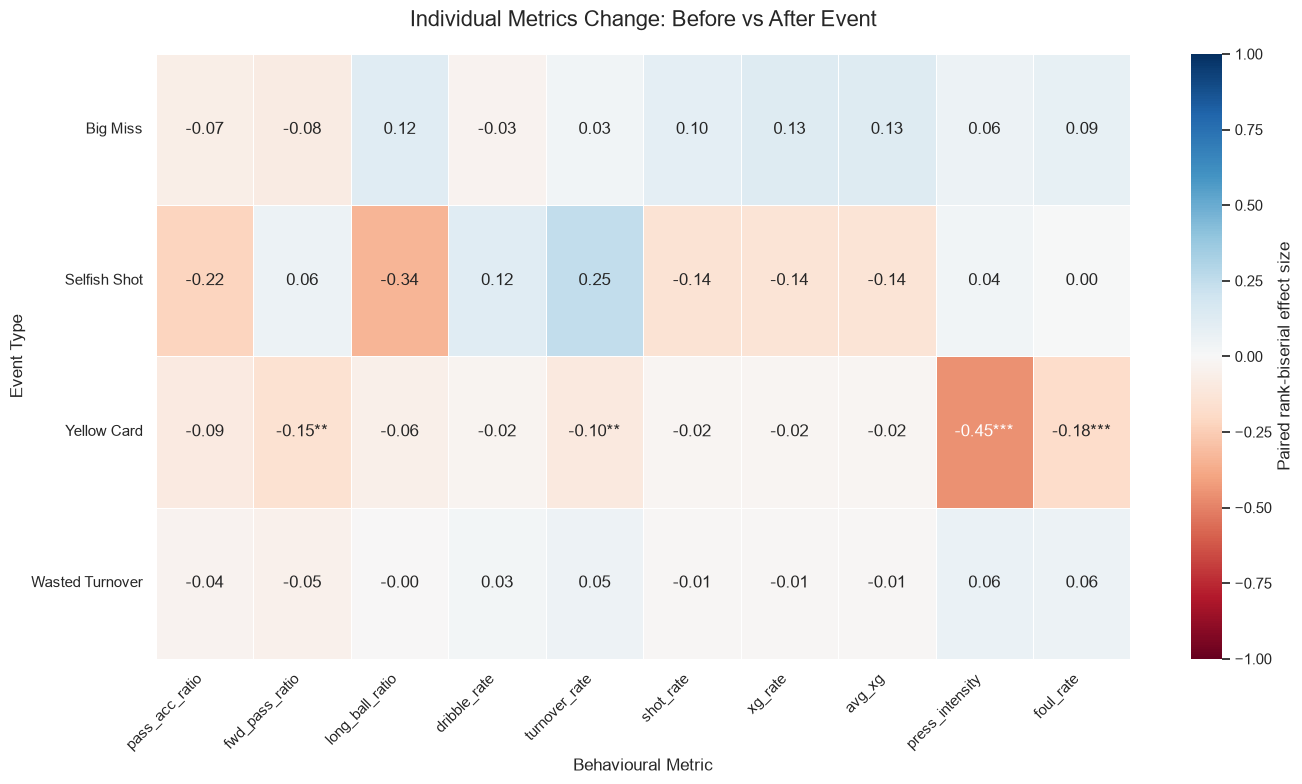

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

def draw_heatmap(df, title, filename):
    heatmap_data = df.pivot(index='event_type', columns='metric', values='cliffs_delta')
    pval_data = df.pivot(index='event_type', columns='metric', values='p_value_fdr')

    heatmap_data = heatmap_data.reindex(index=event_order, columns=metric_order)
    pval_data = pval_data.reindex(index=event_order, columns=metric_order)

    annot_data = heatmap_data.copy().astype(str)

    for row in heatmap_data.index:
        for col in heatmap_data.columns:
            c_delta = heatmap_data.loc[row, col]
            p_val = pval_data.loc[row, col]
            
            if pd.isna(c_delta):
                annot_data.loc[row, col] = ""
                continue
                
            # Stars based on FDR-corrected p-value
            stars = ""
            if p_val < 0.001:
                stars = "***"
            elif p_val < 0.01:
                stars = "**"
            elif p_val < 0.05:
                stars = "*"
                
            annot_data.loc[row, col] = f"{c_delta:.2f}{stars}"

    # Drawing the heatmap
    plt.figure(figsize=(14, 8))
    sns.set_theme(style="white")

    sns.heatmap(
        heatmap_data, 
        annot=annot_data,
        fmt="",
        cmap="RdBu",          # Red for negative, Blue for positive
        vmin=-1, vmax=1,      # Paired rank-biserial effect-size boundaries
        center=0,
        linewidths=.5,
        cbar_kws={'label': "Paired rank-biserial effect size"}
    )

    # Formatting the plot
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel('Behavioural Metric', fontsize=12)
    plt.ylabel('Event Type', fontsize=12)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

if MODE == 'PDE':
    draw_heatmap(results_df, 'Individual Metrics Change: Before vs After Event', 'output/individual/analysis/heatmap_before_vs_after.png')

In [11]:
from scipy.stats import wilcoxon, rankdata

def paired_rank_biserial(differences):
    differences = np.asarray(differences, dtype=float)
    nonzero_differences = differences[~np.isclose(differences, 0)]
    if len(nonzero_differences) == 0:
        return 0.0

    ranks = rankdata(np.abs(nonzero_differences), method='average')
    positive_rank_sum = ranks[nonzero_differences > 0].sum()
    negative_rank_sum = ranks[nonzero_differences < 0].sum()
    return (positive_rank_sum - negative_rank_sum) / ranks.sum()

# Keep only protagonist observations from players with sufficient repeated exposure.
eligible_event_keys = event_player_coverage_df[['player_id', 'event_type']].drop_duplicates()
event_level_df = event_df.merge(
    eligible_event_keys,
    on=['player_id', 'event_type'],
    how='inner'
)

secondary_test_results = []
event_types = event_level_df['event_type'].dropna().unique()

for event in event_types:
    event_data = event_level_df[event_level_df['event_type'] == event]
    control_data = control_event_df[control_event_df['event_type'] == event]
    
    for metric in metrics:
        post_col = f'post_{metric}'
        
        # Average the three control players so each protagonist event contributes one pair.
        control_means = (
            control_data.groupby('paired_event_id', as_index=False)[post_col]
            .mean()
            .rename(columns={post_col: 'control_mean'})
        )
        comparison = (
            event_data[['event_id', post_col]]
            .drop_duplicates('event_id')
            .merge(control_means, left_on='event_id', right_on='paired_event_id', how='inner')
            .dropna(subset=[post_col, 'control_mean'])
        )
        
        differences = (comparison[post_col] - comparison['control_mean']).to_numpy(dtype=float)
        differences = differences[np.isfinite(differences)]
        
        if len(differences) < MIN_TEST_OBSERVATIONS or np.all(np.isclose(differences, 0)):
            p_val = 1.0 if len(differences) >= MIN_TEST_OBSERVATIONS else np.nan
            effect_size = 0.0 if len(differences) >= MIN_TEST_OBSERVATIONS else np.nan
        else:
            _, p_val = wilcoxon(differences, zero_method='wilcox', alternative='two-sided')
            effect_size = paired_rank_biserial(differences)
        
        secondary_test_results.append({
            'event_type': event,
            'metric': metric,
            'n_players_event': len(differences),
            'n_players_control': len(differences),
            'cliffs_delta': effect_size,
            'p_value_raw': p_val
        })

secondary_results_df = pd.DataFrame(secondary_test_results)

reject, pvals_corrected, _, _ = multipletests(
    pvals=secondary_results_df['p_value_raw'].fillna(1.0),
    alpha=0.05,
    method='fdr_bh'
)

secondary_results_df['p_value_fdr'] = pvals_corrected
secondary_results_df['is_significant'] = reject
secondary_results_df.sort_values(by=['event_type', 'metric'], inplace=True)

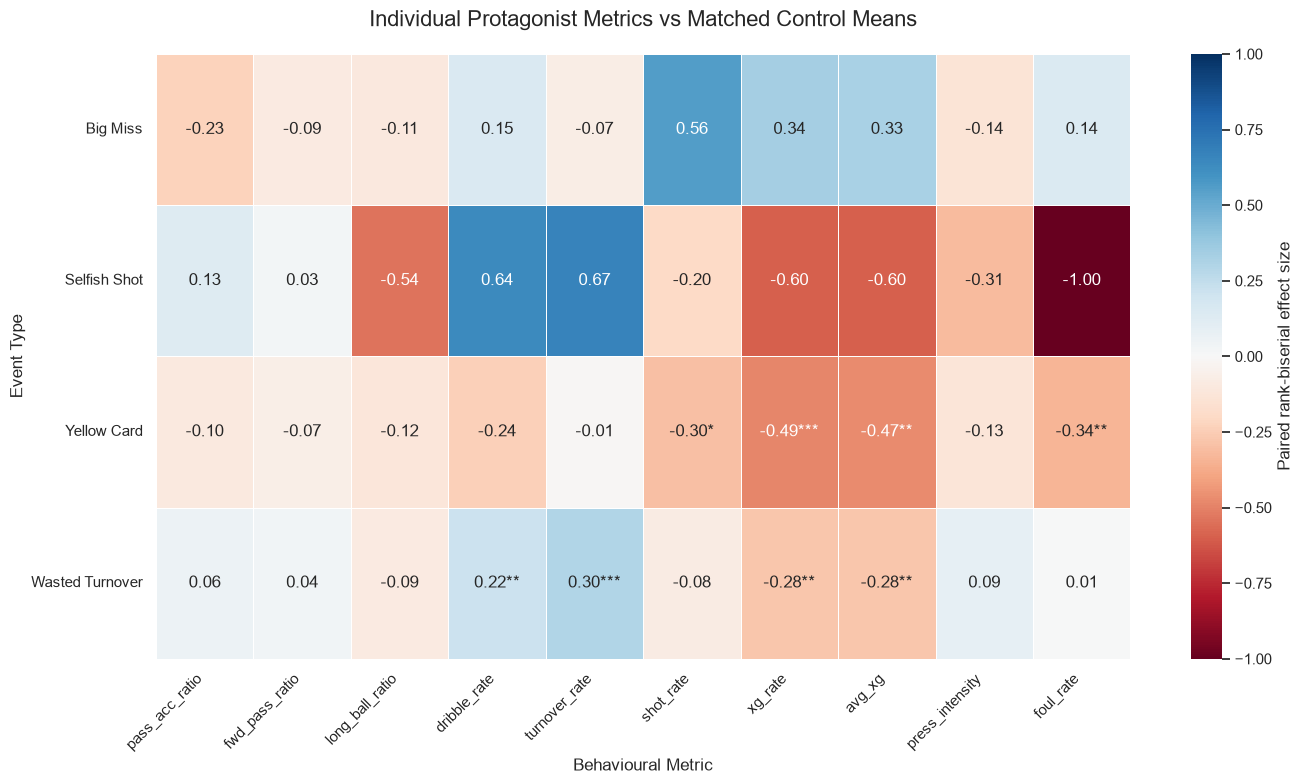

In [12]:
if MODE == 'PDE':
    draw_heatmap(secondary_results_df, 'Individual Protagonist Metrics vs Matched Control Means', 'output/individual/analysis/heatmap_post_vs_control.png')


In [13]:
# 1 sample Wilcoxon test for Z-scores
z_test_results = []

for event in event_types:
    event_data = pooled_event_df[pooled_event_df['event_type'] == event]
    
    for metric in metrics:
        z_col = f'z_score_{metric}'
        
        # Skip if the z-score column does not exist for the current metric
        if z_col not in event_data.columns:
            continue
            
        # Only keep valid (non-NaN) z-score values
        z_vals = event_data[z_col].dropna().values
        
        # Check for sufficient sample size and non-zero variance
        if len(z_vals) < MIN_TEST_OBSERVATIONS or np.all(z_vals == 0):
            p_val = np.nan
            mean_z = np.nan
        else:
            # 1 sample Wilcoxon test
            stat, p_val = wilcoxon(z_vals, zero_method='pratt')
            mean_z = np.mean(z_vals)
            
        z_test_results.append({
            'event_type': event,
            'metric': metric,
            'n_players': len(z_vals),
            'mean_z_score': mean_z,
            'p_value_raw': p_val
        })

z_results_df = pd.DataFrame(z_test_results)

# FDR correction for Z-score tests
reject, pvals_corrected, _, _ = multipletests(
    pvals=z_results_df['p_value_raw'].fillna(1.0), 
    alpha=0.05, 
    method='fdr_bh'
)
z_results_df['p_value_fdr'] = pvals_corrected
z_results_df['is_significant'] = reject

# Prepare data for heatmap
heatmap_data = z_results_df.pivot(index='event_type', columns='metric', values='mean_z_score')
pval_data = z_results_df.pivot(index='event_type', columns='metric', values='p_value_fdr')

# Use the same event and metric order as before for consistency
heatmap_data = heatmap_data.reindex(index=event_order, columns=metric_order)
pval_data = pval_data.reindex(index=event_order, columns=metric_order)

annot_data = heatmap_data.copy().astype(str)

for row in heatmap_data.index:
    for col in heatmap_data.columns:
        z_val = heatmap_data.loc[row, col]
        p_val = pval_data.loc[row, col]
        
        if pd.isna(z_val):
            annot_data.loc[row, col] = ""
            continue
            
        # Stars based on FDR-corrected p-value
        stars = ""
        if p_val < 0.001:
            stars = "***"
        elif p_val < 0.01:
            stars = "**"
        elif p_val < 0.05:
            stars = "*"
            
        annot_data.loc[row, col] = f"{z_val:.2f}{stars}"

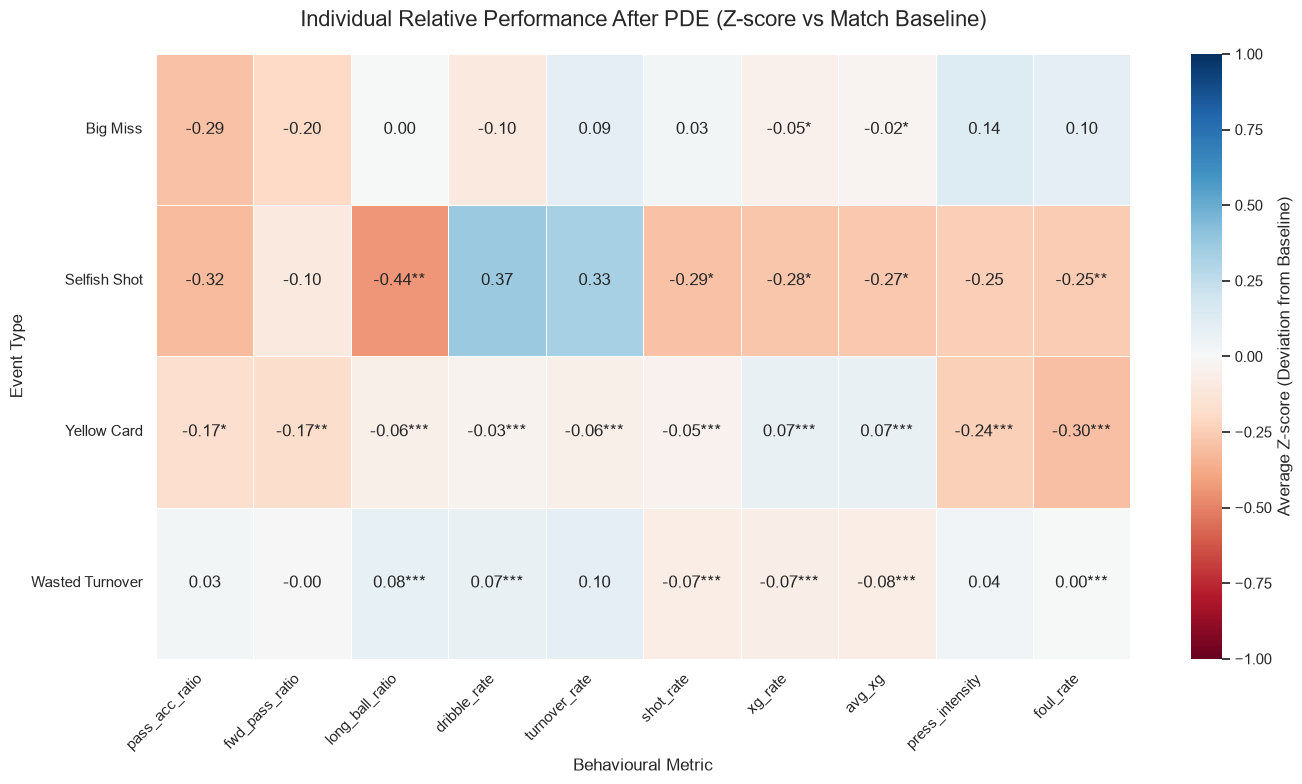

In [14]:
# Draw the heatmap for Z-scores
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

sns.heatmap(
    heatmap_data, 
    annot=annot_data,
    fmt="",
    cmap="RdBu",          
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5,
    cbar_kws={'label': "Average Z-score (Deviation from Baseline)"}
)

title_prefix = {'PDE': 'PDE', 'PFE': 'PFE'}[MODE]
plt.title(f'Individual Relative Performance After {title_prefix} (Z-score vs Match Baseline)', fontsize=16, pad=20)
plt.xlabel('Behavioural Metric', fontsize=12)
plt.ylabel('Event Type', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Save file
if MODE == 'PDE':
    plt.savefig('output/individual/analysis/heatmap_z_score_relative.png', dpi=300)

plt.show()

In [15]:
contagion_test_results = []
event_types = contagion_df['event_type'].unique()

for event in event_types:
    event_data = pooled_contagion_df[pooled_contagion_df['event_type'] == event]
    
    for metric in metrics:
        rel_col = f'relative_diff_z_{metric}'
        
        if rel_col not in event_data.columns:
            continue
            
        rel_vals = event_data[rel_col].dropna().values
        
        if len(rel_vals) < MIN_TEST_OBSERVATIONS or np.all(rel_vals == 0):
            p_val = np.nan
            mean_diff = np.nan
        else:
            stat, p_val = wilcoxon(rel_vals, zero_method='pratt')
            mean_diff = np.mean(rel_vals)
            
        contagion_test_results.append({
            'event_type': event,
            'metric': metric,
            'n_players': len(rel_vals),
            'mean_relative_diff': mean_diff,
            'p_value_raw': p_val
        })

contagion_results_df = pd.DataFrame(contagion_test_results)

reject, pvals_corrected, _, _ = multipletests(
    pvals=contagion_results_df['p_value_raw'].fillna(1.0), 
    alpha=0.05, 
    method='fdr_bh'
)

contagion_results_df['p_value_fdr'] = pvals_corrected

heatmap_data_cont = contagion_results_df.pivot(index='event_type', columns='metric', values='mean_relative_diff')
pval_data_cont = contagion_results_df.pivot(index='event_type', columns='metric', values='p_value_fdr')

heatmap_data_cont = heatmap_data_cont.reindex(index=event_order, columns=metric_order)
pval_data_cont = pval_data_cont.reindex(index=event_order, columns=metric_order)

annot_data_cont = heatmap_data_cont.copy().astype(str)

for row in heatmap_data_cont.index:
    for col in heatmap_data_cont.columns:
        diff_val = heatmap_data_cont.loc[row, col]
        p_val = pval_data_cont.loc[row, col]
        
        if pd.isna(diff_val):
            annot_data_cont.loc[row, col] = ""
            continue
            
        stars = ""
        if p_val < 0.001:
            stars = "***"
        elif p_val < 0.01:
            stars = "**"
        elif p_val < 0.05:
            stars = "*"
            
        annot_data_cont.loc[row, col] = f"{diff_val:.2f}{stars}"

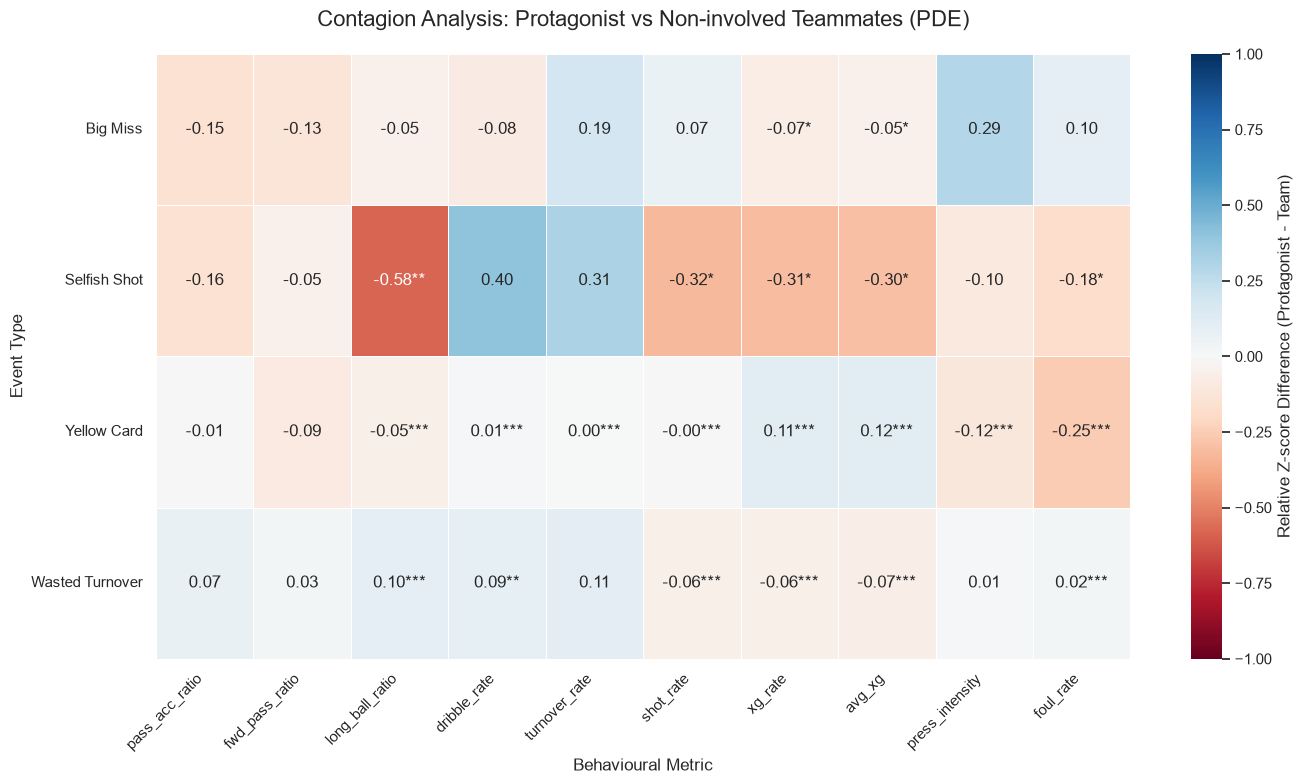

In [16]:
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

sns.heatmap(
    heatmap_data_cont, 
    annot=annot_data_cont,
    fmt="",
    cmap="RdBu",          
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Relative Z-score Difference (Protagonist - Team)'}
)

title_prefix = {'PDE': 'PDE', 'PFE': 'PFE'}[MODE]
plt.title(f'Contagion Analysis: Protagonist vs Non-involved Teammates ({title_prefix})', fontsize=16, pad=20)
plt.xlabel('Behavioural Metric', fontsize=12)
plt.ylabel('Event Type', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

if MODE == 'PDE':
    plt.savefig('output/individual/analysis/heatmap_contagion_analysis.png', dpi=300)

plt.show()